# Facial Emotion Recognition — Full Pipeline

This notebook reproduces the complete project pipeline end to end, from raw
FER-2013 images to final trained SVM models. Each cell runs one script and
displays its outputs inline.

## Step 1 — Clone repos

On your terminal:

```bash
cd wherever/your/folder/is
git clone https://github.com/werka-z/emotion-recognition.git emotion-recognition-test
git clone https://github.com/mselezniova/AppliedML.git
```

At the end, you should have:

```
parent_folder/
└── AppliedML/                 (courselib)
├── emotion-recognition-test/  (this repo)
    └── everything else from the repo (already cloned)
```

Download the data from [Kaggle](https://www.kaggle.com/datasets/msambare/fer2013/data) and place it in the `data` folder of the `emotion-recognition-test` repo. Also download dlib's detector from [dlib.net](http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2), click on the `.bz2` file to turn it into a `.dat` file, and place the `.dat` file at the repo root.

It should look like this:

```
parent_folder/
├── AppliedML/                                     (courselib)
└── emotion-recognition-test/                       (this repo)
    ├── data/                                       (downloaded data)
    └── shape_predictor_68_face_landmarks.dat        (downloaded detector)
    └── everything else from the repo (already cloned)
```

## Step 2 — Create environments from yml files

The dlib environment has specific dependencies (at least on my mac). That is why we need 2 separate environments to run this notebook.

```bash
cd emotion-recognition-test

# dlib environment
conda env create -f environment.yml
# This creates fer_feature_extraction

# appliedml environment
conda env create -f environment_appliedml.yml
# This creates appliedml
```

## Step 3 — Run the notebook

Open the Jupyter Notebook in your IDE and choose the kernel according to the markdown cells.
Pay attention to warnings about when to switch kernels!

### Two conda environments required

| Part | Environment | Kernel to select |
|------|-------------|-------------------|
| Part 1 — Preprocessing & extraction | `fer_feature_extraction` (dlib) | Python [conda env: fer_feature_extraction] |
| Part 2 — SVM training & evaluation | `appliedml` (courselib + cvxopt) | Python [conda env: aml] |

Switch kernel between parts: **Kernel → Change Kernel → Python [conda env: ...]**

---

### Run from the repo root

```bash
cd /path/to/emotion-recognition
jupyter notebook pipeline_notebook.ipynb
```

In [1]:
import os
# Verify we are in the right directory
assert os.path.exists("paths.py"), (
    "paths.py not found. Make sure the notebook is opened from the "
    "emotion-recognition/ root directory.")
print("Working directory:", os.getcwd())
print("paths.py found ✓")

Working directory: /Users/dogadevrimcelik/Desktop/final_try/emotion-recognition-test
paths.py found ✓


---
# Part 1 — Preprocessing Ablation & Feature Extraction
**⚠️ Switch kernel to `fer_feature_extraction` (dlib) before running this section.**

FER-2013 images are 48×48 grayscale — too small for dlib's face detector and
68-point landmark predictor, which were trained on higher-resolution, naturally-lit
images. This part systematically investigates preprocessing choices (upscaling
resolution, contrast enhancement) to maximise landmark detection quality before
extracting geometric features.

## Step 1 — Compare upscaling resolutions

**Script:** `ablation_studies/compare_upscaling.py`  
**Output:** `ablation_results/upscaling/`  
**Requires:** dlib env  

**Runtime**: 12 mins

dlib's face detector fails on roughly 9% of FER-2013 images at native 48×48
resolution. This script tests five upscaling resolutions (96, 144, 192, 240, 288px)
against the 48px baseline and records the detection rate at each scale. Upscaling
does not add real information, but it gives the HOG-based detector a larger
effective working resolution — at the cost of slower processing.

The detection rate plateaus around 144px; larger scales offer diminishing returns
while substantially increasing runtime. All subsequent pipeline steps use 144px.

In [2]:
import subprocess, sys
result = subprocess.run([sys.executable, 'ablation_studies/compare_upscaling.py'], capture_output=False)
print("Return code:", result.returncode)


Upscale 1x  (48x48 px)
  train ...
  → detected 20001/28709  (69.7%)
  test ...
  → detected 4958/7178  (69.1%)

Upscale 2x  (96x96 px)
  train ...
  → detected 22100/28709  (77.0%)
  test ...
  → detected 5547/7178  (77.3%)

Upscale 3x  (144x144 px)
  train ...
  → detected 22578/28709  (78.6%)
  test ...
  → detected 5652/7178  (78.7%)

Upscale 4x  (192x192 px)
  train ...
  → detected 21627/28709  (75.3%)
  test ...
  → detected 5417/7178  (75.5%)

Upscale 5x  (240x240 px)
  train ...
  → detected 22070/28709  (76.9%)
  test ...
  → detected 5532/7178  (77.1%)

Upscale 6x  (288x288 px)
  train ...
  → detected 22069/28709  (76.9%)
  test ...
  → detected 5531/7178  (77.1%)

TRAIN split — detection rate (%) by upscale factor
-------------------------------------------------------
Emotion         1x (48px)  2x (96px)  3x (144px)  4x (192px)  5x (240px)  6x (288px)
------------------------------------------------------------------------------------
Angry                68.8%       76.

## Step 2 — Plot upscaling results

**Script:** `ablation_studies/plot_upscaling.py`  
**Output:** `ablation_results/upscaling/fig_detection_counts.png`, `fig_upscaling_comparison.png`

Plots detection rate as a function of upscaling resolution. The left panel shows
absolute detection counts per emotion class; the right panel shows the aggregate
detection rate across all resolutions.

In [3]:
import subprocess, sys
result = subprocess.run([sys.executable, 'ablation_studies/plot_upscaling.py'], capture_output=False)
print("Return code:", result.returncode)

Saved compare_upscaling.png → /Users/dogadevrimcelik/Desktop/final_try/emotion-recognition-test/ablation_results/upscaling/
Best upscale factor: 3x (144x144 px)
Saved compare_upscaling_best.png → /Users/dogadevrimcelik/Desktop/final_try/emotion-recognition-test/ablation_results/upscaling/
Return code: 0


### Best detection plot

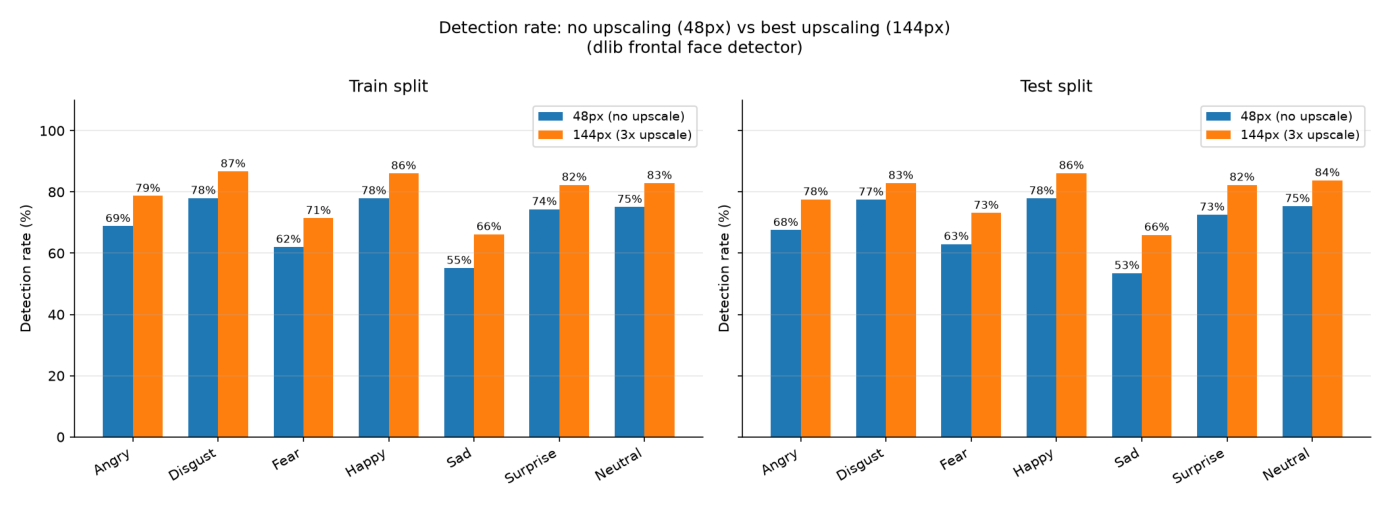

In [4]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'ablation_results/upscaling/compare_upscaling_best.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Detection rate comparison


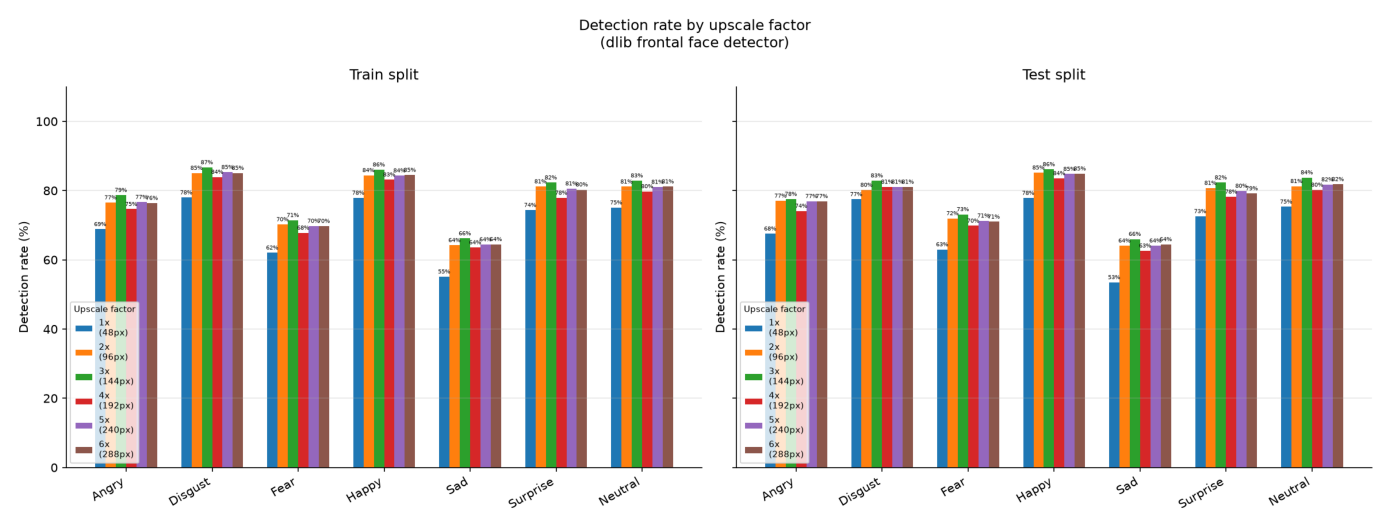

In [5]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'ablation_results/upscaling/compare_upscaling.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

## Step 3 — Show detection failures

**Script:** `ablation_studies/show_detection_failures.py`  
**Output:** `ablation_results/upscaling/failures_hard.png`, `failures_recovered.png`

Visualises two categories of detection outcome:

- **Recovered images** : failed at 48px but successfully detected at 144px. These
  are typically frontal faces that simply lacked sufficient pixel detail at normal
  resolution. The majority of previously-dropped samples fall here.
- **Hard failures** : failed at both 48px and 144px. These are problematic
  samples: non-photographic content, watermarks, blank frames, extreme occlusion, or non-frontal poses. No preprocessing can fix these;
  they are excluded from all subsequent training data.

In [6]:
import subprocess, sys
result = subprocess.run([sys.executable, 'ablation_studies/show_detection_failures.py'], capture_output=False)
print("Return code:", result.returncode)

(this may take a few minutes)

  Angry         recovered: 5  hard fails: 5
  Disgust       recovered: 5  hard fails: 5
  Fear          recovered: 5  hard fails: 5
  Happy         recovered: 5  hard fails: 5
  Sad           recovered: 5  hard fails: 5
  Surprise      recovered: 5  hard fails: 5
  Neutral       recovered: 5  hard fails: 5
Saved failures_recovered.png → /Users/dogadevrimcelik/Desktop/final_try/emotion-recognition-test/ablation_results/upscaling/
Saved failures_hard.png → /Users/dogadevrimcelik/Desktop/final_try/emotion-recognition-test/ablation_results/upscaling/
Return code: 0


### Recovered by upscaling (failed at 48px, detected at 144px)


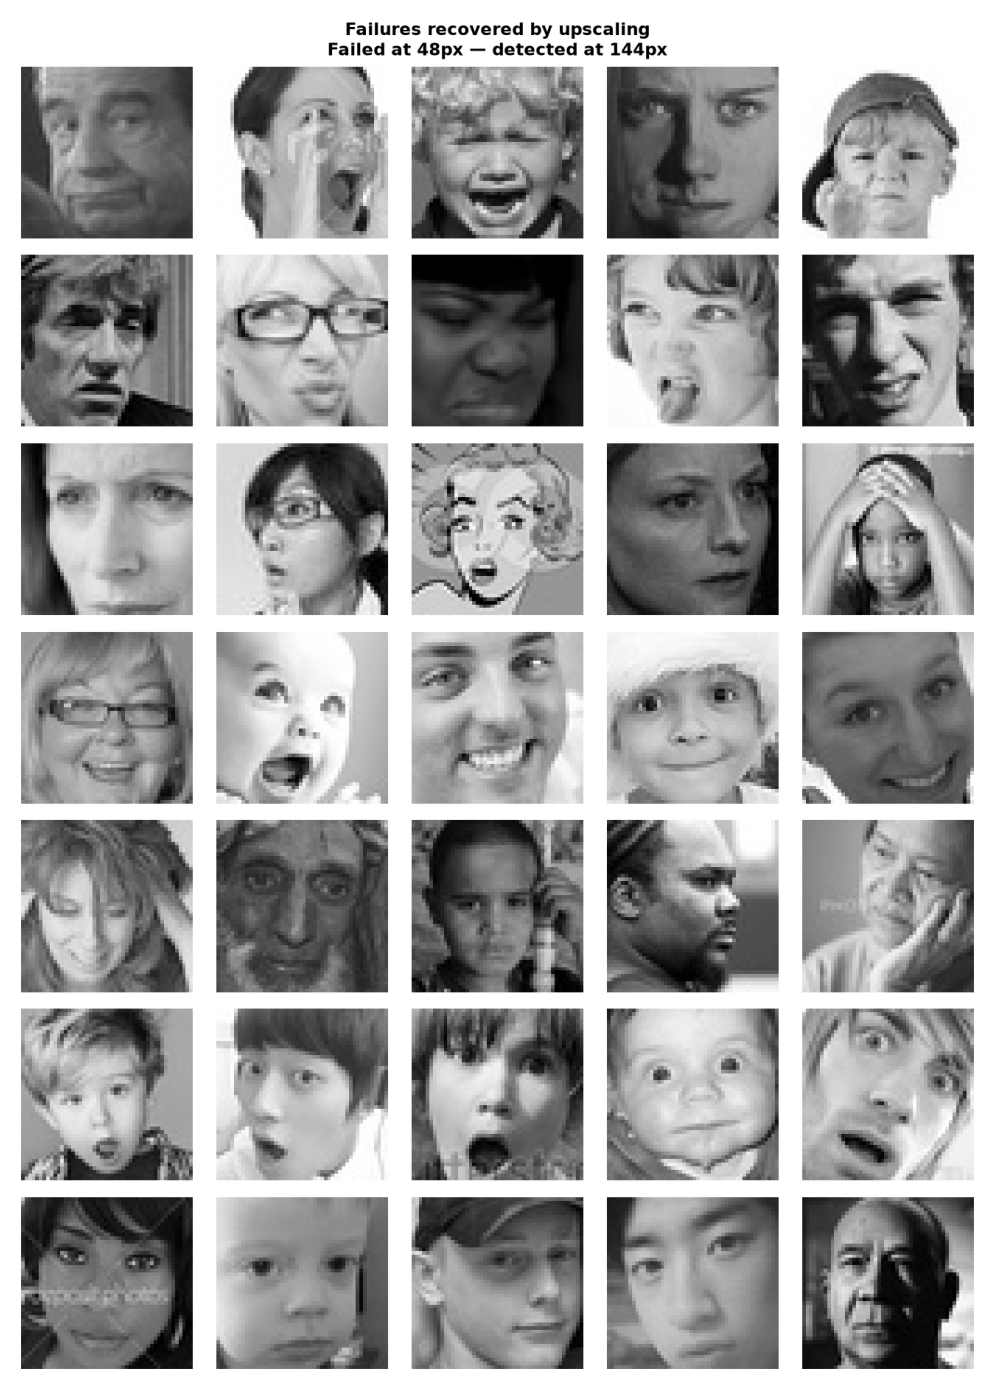

In [7]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'ablation_results/upscaling/failures_recovered.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(12, 14))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Hard failures (failed at both 48px and 144px)

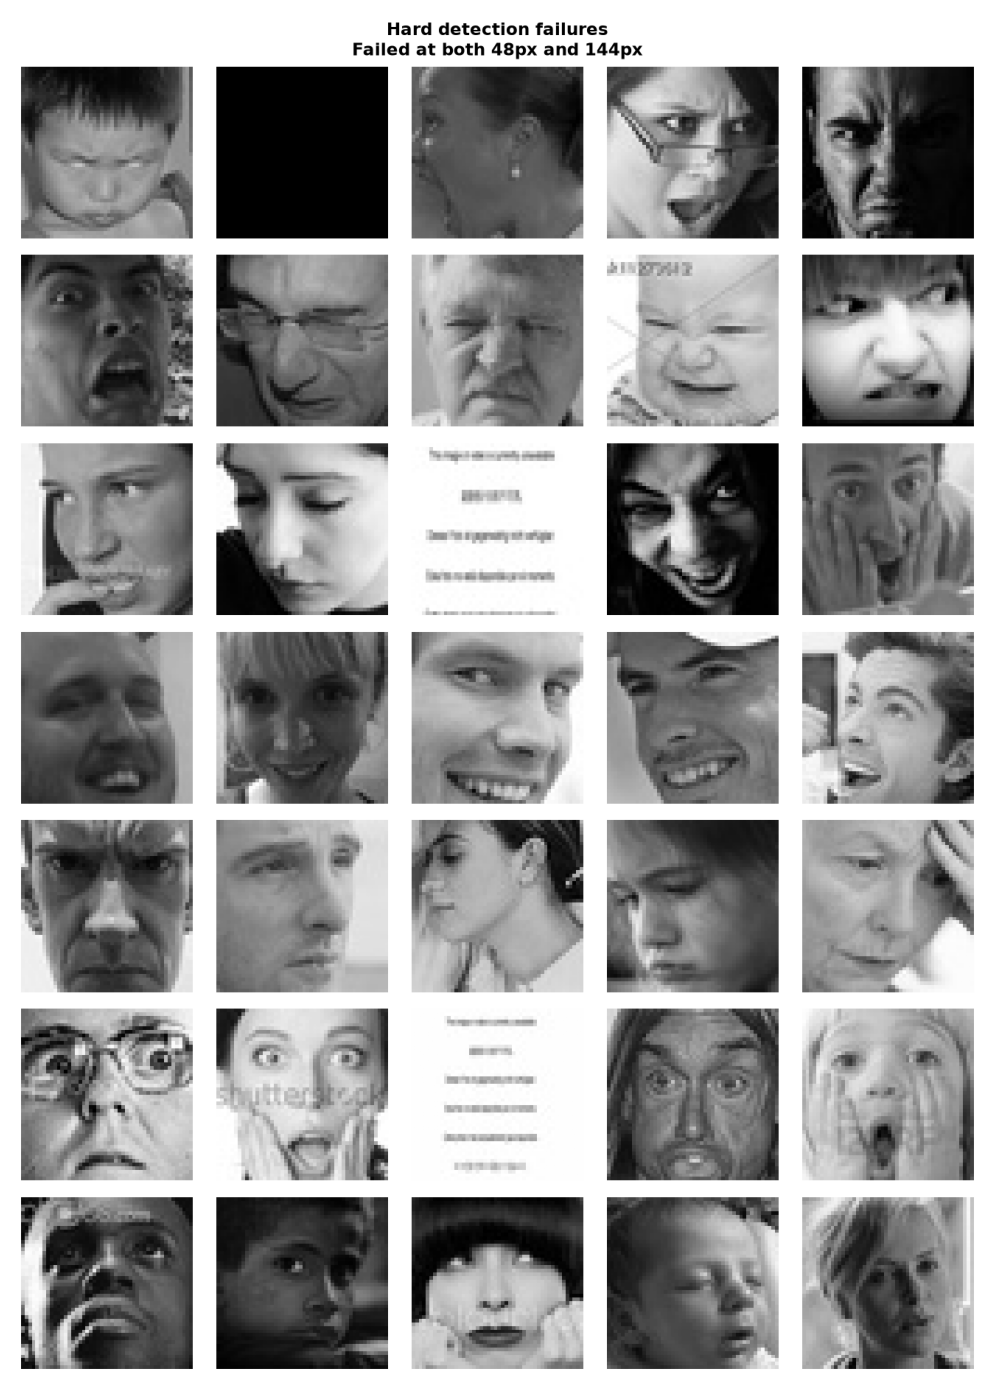

In [8]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'ablation_results/upscaling/failures_hard.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(12, 14))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

## Step 4 — Compare all preprocessing conditions

**Script:** `ablation_studies/compare_all_preprocessing.py`  
**Output:** `ablation_results/clahe/`

**Runtime:** 3 mins

Tests all four combinations of upscaling (on/off) × CLAHE contrast enhancement
(on/off) on dlib's detector. CLAHE (Contrast Limited Adaptive Histogram Equalization) locally
redistributes pixel intensities to improve contrast, which is commonly used for
low-quality face datasets.

The intuition for testing CLAHE: FER-2013 images vary widely in lighting and
contrast, and CLAHE might help the detector pick up facial structure in dark
or very bright images. In practice, CLAHE's local contrast amplification also
introduces high-frequency noise and JPEG artifacts in the already low-resolution
images, which can confuse the later models (investigated in SVM models in the later cells)

In [9]:
import subprocess, sys
result = subprocess.run([sys.executable, 'ablation_studies/compare_all_preprocessing.py'], capture_output=False)
print("Return code:", result.returncode)


no_up_no_cl  (upscale=False  clahe=False)
  train ...
  → detected 20001/28709  (69.7%)
  test ...
  → detected 4958/7178  (69.1%)

no_up_cl  (upscale=False  clahe=True)
  train ...
  → detected 20213/28709  (70.4%)
  test ...
  → detected 5042/7178  (70.2%)

up_no_cl  (upscale=True  clahe=False)
  train ...
  → detected 22578/28709  (78.6%)
  test ...
  → detected 5652/7178  (78.7%)

up_cl  (upscale=True  clahe=True)
  train ...
  → detected 22670/28709  (79.0%)
  test ...
  → detected 5685/7178  (79.2%)

TRAIN split — detection rate (%) per condition
--------------------------------------------------
  Emotion        no_up_no_cl      no_up_cl      up_no_cl         up_cl
--------------------------------------------------
  Angry                68.8%         69.0%         78.7%         78.2%
  Disgust              78.0%         78.0%         86.7%         86.2%
  Fear                 62.0%         62.3%         71.4%         71.5%
  Happy                77.9%         79.8%         86.

## Step 5 — Plot CLAHE comparison

**Script:** `ablation_studies/plot_clahe.py`  
**Output:** `ablation_results/clahe/fig_clahe_comparison.png`

Plots detection rate across all four conditions side by side. While CLAHE
produces a marginal improvement in raw detection rate, later step SVM experiments
show it consistently drops classification performance. Possibly the landmark
predictor is sensitive to the artificial high-frequency structure CLAHE introduces,
producing less reliable landmark positions even when the detector finds a face.


In [10]:
import subprocess, sys
result = subprocess.run([sys.executable, 'ablation_studies/plot_clahe.py'], capture_output=False)
print("Return code:", result.returncode)

Saved compare_clahe.png → /Users/dogadevrimcelik/Desktop/final_try/emotion-recognition-test/ablation_results/clahe/
Return code: 0


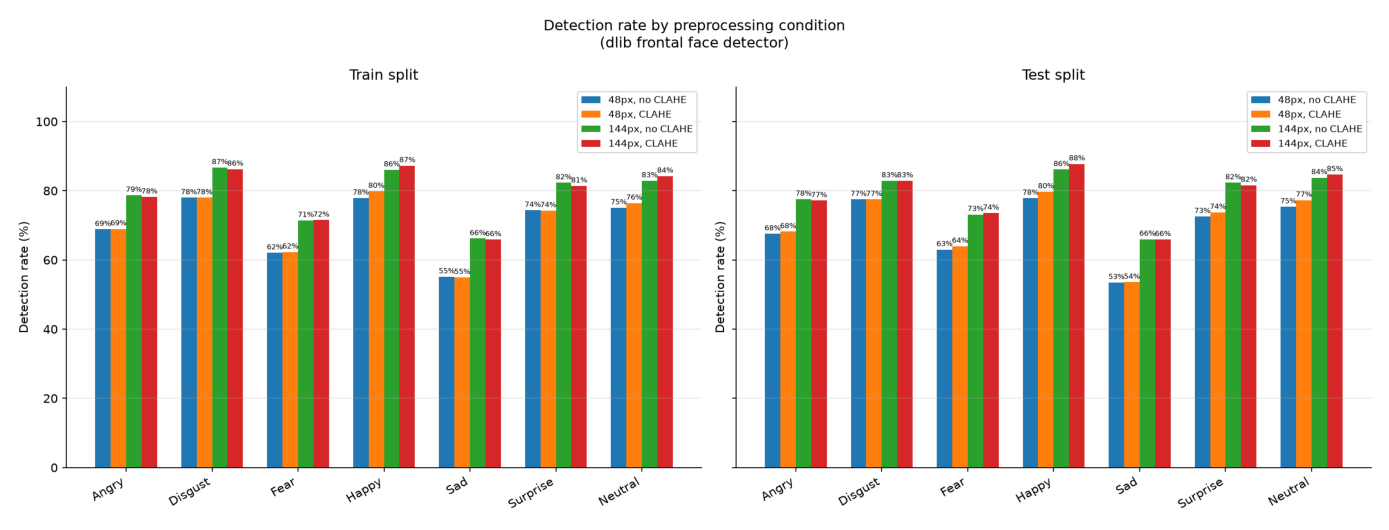

In [11]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'ablation_results/clahe/compare_clahe.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

## Step 6 — Extract features for ablation (all 4 conditions)

**Script:** `ablation_studies/extract_ablation.py`  
**Output:** `ablation_results/features/{condition}_X_train.npy`, `_y_train.npy`, `_X_test.npy`, `_y_test.npy`  
**Expected runtime: ~5 minutes**

Extracts all 28 geometric features from 68 dlib facial landmarks for each of the
four preprocessing conditions. Features are extracted separately per condition so
the SVM ablation can fairly compare preprocessing choices on identical
model configurations.

The 28 features are FACS-inspired geometric measurements normalised by inter-ocular
distance (IOD) for scale invariance. Feature selection (ANOVA F-statistic) is
applied per condition inside the ablation script to avoid data leakage.

Features and their explanations:

# Eye Features
**EAR avg (Eye Aspect Ratio, average)** Computed as the mean of the left and right eye aspect ratios, where each EAR is the ratio of the vertical eye opening to the horizontal eye width. Captures AU5 (upper lid raise) and AU45 (blink). Wide-open eyes are characteristic of Surprise and Fear, while narrowed eyes are associated with Disgust and Angry.

**EAR asymmetry** The absolute difference between left and right EAR values. Captures unilateral lid tension or winking behaviour. Elevated in expressions involving asymmetric muscle activation.

**Cheek raise** Ratio of the vertical eye opening to the horizontal eye width for the right eye, computed differently from EAR to specifically capture cheek-driven lid narrowing. Captures AU6 (cheek raiser), the Duchenne marker of genuine happiness. Elevated in Happy, also in Surprise.

**Eye open (L) and Eye open (R)** Vertical opening distance of the left and right eyes respectively, normalised by IOD. Added explicitly to capture per-eye AU5 activation. These are the primary indicators of AU5. Surprise produces the largest values; Disgust and Angry produce the smallest.

**Eye open diff** Absolute difference between left and right eye openings. Captures bilateral asymmetry in lid position, which can arise from unilateral muscle tension or natural facial asymmetry. Low F-statistic (F=8) but retained due to visible signal for Disgust in the heatmap analysis.

**Eye corner slant** The average vertical offset between inner and outer eye corners.

# Brow Features

**Brow furrow** Euclidean distance between the inner endpoints of the left and right brows (landmarks 21 and 22). Captures AU4 (brow lowerer). Decreases when brows are pulled together, as in Angry and Disgust. One of the most discriminative brow features.

**Brow raise avg** Average vertical distance between each eye corner and the corresponding brow, measuring how far the brows are lifted above the eyes. Captures AU1+AU2 combined. Elevated in Surprise and Fear; depressed in Angry and Disgust.

**Brow slope (R) and Brow slope (L)** Slope of the right and left brow respectively, computed as the vertical change divided by horizontal change across the brow landmarks. Captures the V-shaped brow depression of AU4. In Angry the inner brows are pulled down, creating a negative slope toward the centre.

**Brow compression** Range of vertical positions across all 10 brow landmarks. Captures how much the brow is compressed vertically, which increases in expressions involving strong brow furrowing (Angry, Disgust).

**Inner brow raise** Vertical distance between the nose bridge landmark and the average of the inner brow landmarks, normalised by IOD. Captures AU1 in isolation. Elevated in Fear and Sad, where the inner brows pull upward while the outer brows remain relatively stable.

**Outer brow raise** Same computation for the outer brow landmarks. Captures AU2. Elevated in Surprise, where both inner and outer brows raise together.

**Brow oblique** Difference between inner and outer brow heights. Captures the oblique brow shape characteristic of Sad and Fear (inner brows raised, outer brows flat), which distinguishes these emotions from Surprise (both raised uniformly).

**Inner brow dist** IOD-normalised distance between the inner endpoints of the two brows. Complementary to brow furrow — captures the spacing between brows rather than the absolute position of each brow tip.


# Mouth Features

**MAR (Mouth Aspect Ratio)** Ratio of vertical mouth opening to horizontal mouth width. Captures AU25 (lips part) and AU26 (jaw drop). Elevated in Surprise and Fear where the mouth falls open; near zero in closed-mouth expressions.

**Lip corner pull** Average upward displacement of the mouth top relative to the lip corners. Captures AU12 (lip corner puller), the primary geometric marker of a smile. Strongly elevated in Happy; the most discriminative mouth feature alongside mouth width.

**Mouth asymmetry** Absolute vertical difference between left and right lip corner positions. Captures AU14 (dimpler) and sneer expressions. 

**Lip corner depress** Average vertical position of the lip corners relative to the upper lip centre, normalised by IOD. Captures AU15 (lip corner depressor). Elevated in Sad where the corners of the mouth pull downward.

**Upper lip raise** Vertical distance from the nose tip to the upper lip centre, normalised by IOD. Captures AU10 (upper lip raiser). Elevated in Disgust where the upper lip curls upward toward the nose.

**Mouth width** Horizontal distance between the left and right lip corners, normalised by IOD. Captures AU20 (lip stretcher). The highest F-statistic of all features. Strongly elevated in Happy (smile widens the mouth) and Fear (lips pull back horizontally).

**Lip gap** Vertical distance between the upper and lower lip at the centre, normalised by IOD. Captures AU26. Directly measures how open the mouth is at the midpoint, complementary to MAR which captures the overall shape ratio.

**Lip corner angle** The angle of the line connecting the two lip corners. 



# Nose and Jaw Features

**Nose-to-mouth** Euclidean distance from the nose tip to the upper lip centre. The second highest F-statistic. In Happy, smiling pulls the lips upward toward the nose, reducing this distance. In Surprise and Sad, the mouth opens or drops, increasing it.

**Jaw drop** Euclidean distance from the chin landmark to the nose bridge. Captures the overall vertical extension of the lower face, which increases when the jaw drops (AU26/27). Elevated in Surprise and Fear.

**Chin-to-mouth** Vertical distance from the chin to the lower lip, normalised by IOD. Captures AU17 (chin raiser). In expressions involving chin tension (Disgust, Sad), the chin pulls upward toward the mouth, reducing this distance.

**Face ratio** Ratio of face height to face width, both normalised by IOD. A structural feature that captures overall face shape rather than expression-specific muscle movement. Retained due to marginal signal across some emotion pairs, though it is the weakest of the retained features.

In [12]:
import subprocess, sys
result = subprocess.run([sys.executable, 'ablation_studies/extract_ablation.py'], capture_output=False)
print("Return code:", result.returncode)


  no_up_no_cl  (upscale=False  clahe=False)
  train:
    kept 20001/28709  (drop 30.3%)
  test:
    kept 4958/7178  (drop 30.9%)

  no_up_cl  (upscale=False  clahe=True)
  train:
    kept 20213/28709  (drop 29.6%)
  test:
    kept 5042/7178  (drop 29.8%)

  up_no_cl  (upscale=True  clahe=False)
  train:
    kept 22578/28709  (drop 21.4%)
  test:
    kept 5652/7178  (drop 21.3%)

  up_cl  (upscale=True  clahe=True)
  train:
    kept 22670/28709  (drop 21.0%)
  test:
    kept 5685/7178  (drop 20.8%)

All done. Files in '/Users/dogadevrimcelik/Desktop/final_try/emotion-recognition-test/ablation_results/features/':
  no_up_cl_X_test.npy  (551.6 KB)
  no_up_cl_X_train.npy  (2210.9 KB)
  no_up_cl_image_paths_test.npy  (2146.9 KB)
  no_up_cl_image_paths_train.npy  (8448.5 KB)
  no_up_cl_y_test.npy  (19.8 KB)
  no_up_cl_y_train.npy  (79.1 KB)
  no_up_no_cl_X_test.npy  (542.4 KB)
  no_up_no_cl_X_train.npy  (2187.7 KB)
  no_up_no_cl_image_paths_test.npy  (2111.1 KB)
  no_up_no_cl_image_paths_tr

---
# ⚠️ Switch kernel to `appliedml` before continuing

**Kernel → Change Kernel → Python [conda env: appliedml]**

This part uses courselib (requires cvxopt and the `appliedml` environment).
The `appliedml` environment must have courselib on the Python path — by default this
is resolved via `paths.py` which looks for the `AppliedML/` sibling repo.

## Step 7 — Linear SVM ablation

**Script:** `ablation_studies/linear_svm_ablation.py`  
**Output:** `ablation_results/linear_svm_ablation/`  
**Runtime: ~10 minutes**

Full ablation of the C-parameterized linear SVM.

The ablation sweeps:
- **4 preprocessing conditions** × **4 scaling settings** × **2 class weighting options**
- **C ∈ {1, 10, 100, 1000}** 
- **11 feature counts**: 5, 8, 10, 12, 15, 18, 20, 22, 24, 26, 28

Class weighting is our own extension beyond the course material, motivated by FER-2013's severe imbalance
(Disgust ~500 samples vs Happy ~8,000).

**Total: 1,536 model fits × 100 epochs.** 

Primary metric: **macro F1** (chosen over
accuracy because class imbalance makes accuracy misleading).
Prints only the best values for that grid

In [1]:
import subprocess, sys
result = subprocess.run([sys.executable, 'ablation_studies/linear_svm_ablation.py'], capture_output=False)
print("Return code:", result.returncode)


  Step 1: Feature count sweep

  Feature count sweep over [5, 8, 10, 12, 15, 18, 20, 22, 24, 26, 28]


  n=5 features
    [SVM (C=1)]  best acc=0.4030  best mac=0.2129
    [SVM (C=10)]  best acc=0.4223  best mac=0.2661
    [SVM (C=100)]  best acc=0.4324  best mac=0.2899
    [SVM (C=1000)]  best acc=0.4296  best mac=0.2929

  n=8 features
    [SVM (C=1)]  best acc=0.4292  best mac=0.2324
    [SVM (C=10)]  best acc=0.4435  best mac=0.2903
    [SVM (C=100)]  best acc=0.4558  best mac=0.3093
    [SVM (C=1000)]  best acc=0.4623  best mac=0.3225

  n=10 features
    [SVM (C=1)]  best acc=0.4344  best mac=0.2399
    [SVM (C=10)]  best acc=0.4484  best mac=0.2935
    [SVM (C=100)]  best acc=0.4644  best mac=0.3179
    [SVM (C=1000)]  best acc=0.4733  best mac=0.3428

  n=12 features
    [SVM (C=1)]  best acc=0.4457  best mac=0.2660
    [SVM (C=10)]  best acc=0.4671  best mac=0.3144
    [SVM (C=100)]  best acc=0.4832  best mac=0.3461
    [SVM (C=1000)]  best acc=0.4935  best mac=0.3608

  n=15

### Feature count sweep
Macro F1 and accuracy vs number of features, for each C value. Performance rises monotonically up to n=26 (macro F1) and n=28 (accuracy) — the difference between the two is within noise, so n=26 is used throughout.

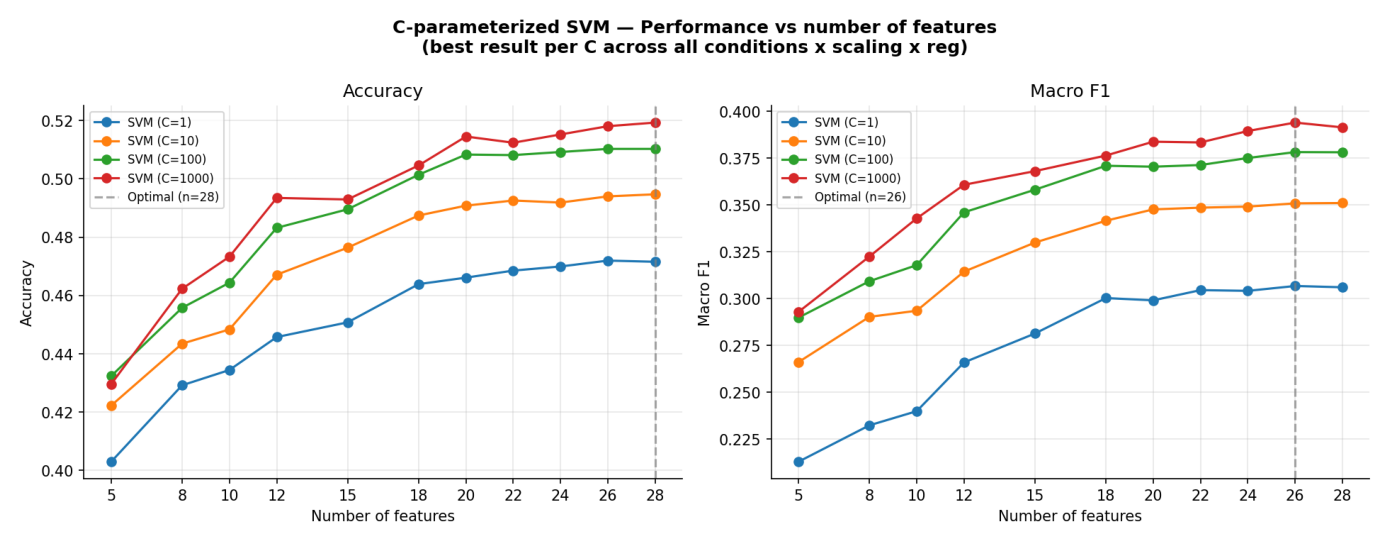

In [2]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'ablation_results/linear_svm_ablation/feature_sweep/fig_feature_count_sweep.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Macro F1 heatmap (26 features)
Rows = C value, columns = scaling setting. Each cell shows macro F1 for the best preprocessing condition and class weighting combination at that C × scale point. The starred cell is the global best. `no_scale` collapses across the board; `clip3` and `clip2` are consistently best.

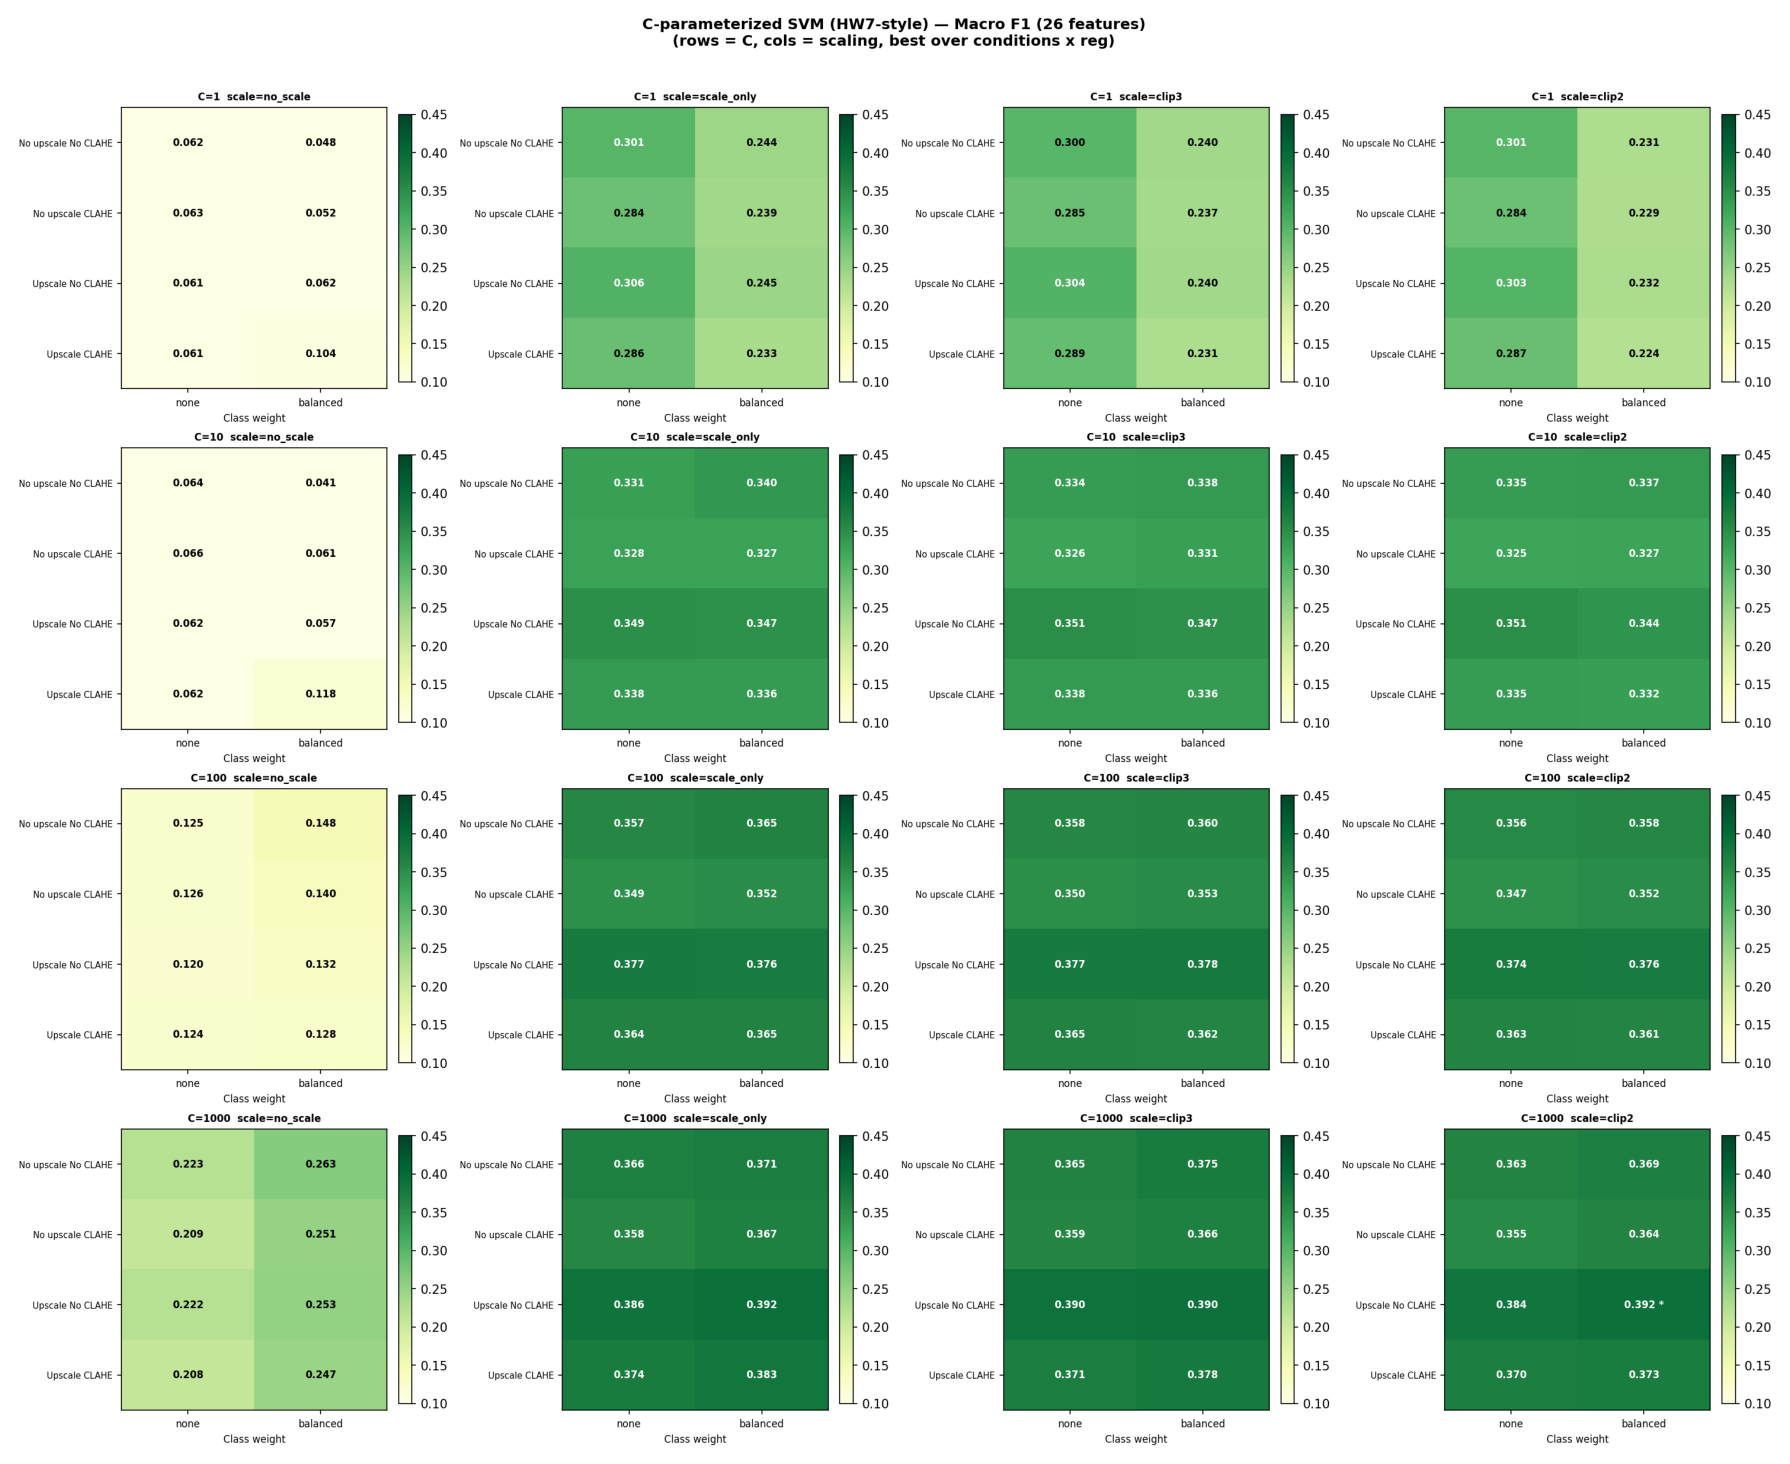

In [3]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'ablation_results/linear_svm_ablation/26feat/fig_macro_f1_heatmap.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(18, 22))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Best configurations
Left: best macro F1 configuration (balanced class weighting recovers Disgust recall at a ~5pp accuracy cost). Right: best accuracy configuration (no weighting, higher accuracy but Disgust recall = 0%).

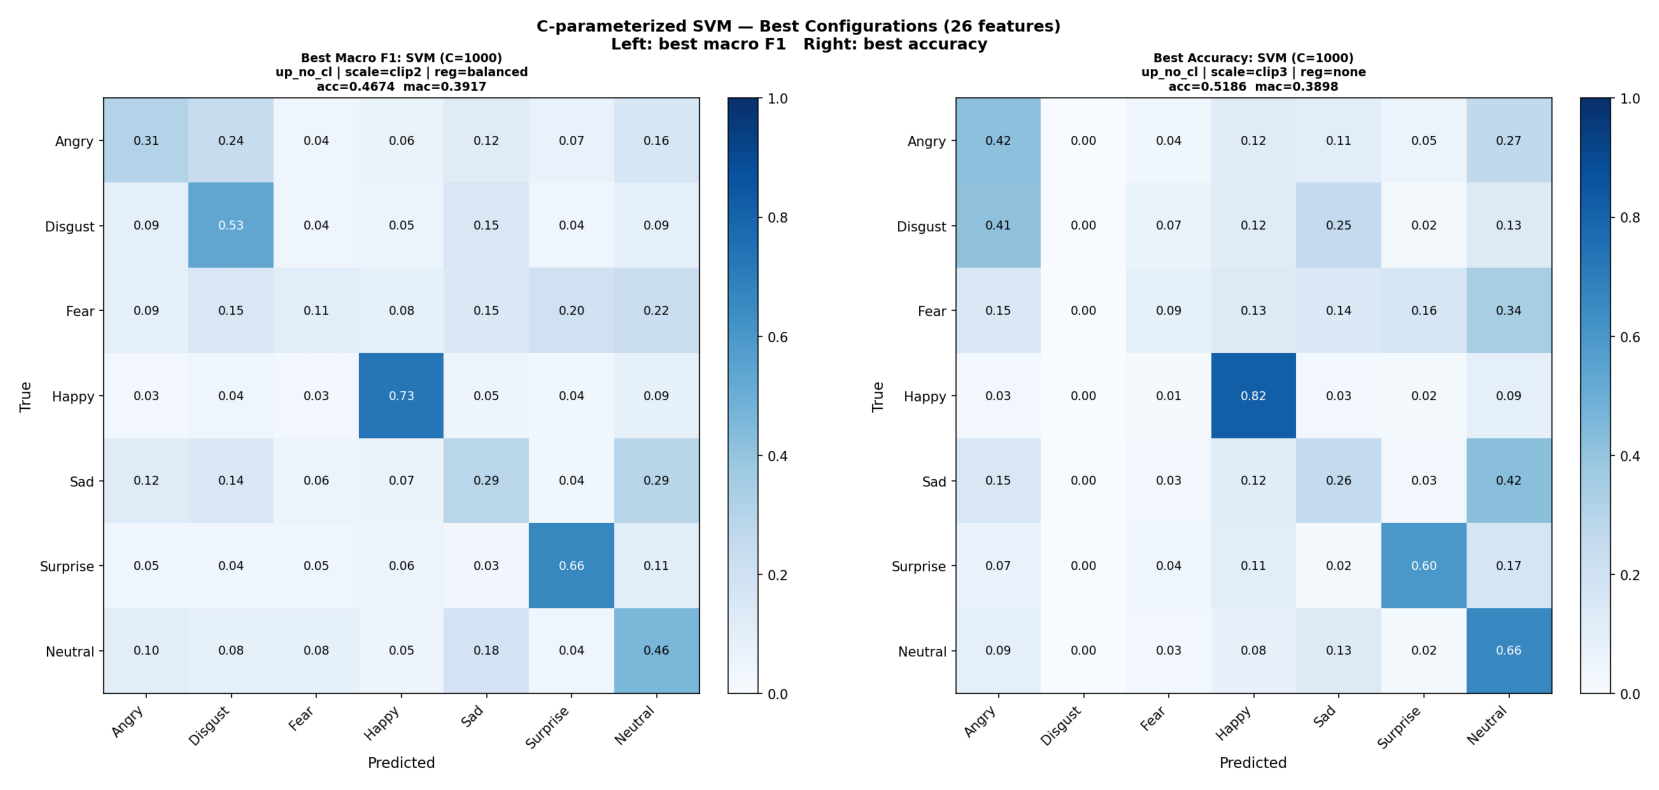

In [4]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'ablation_results/linear_svm_ablation/26feat/fig_best_cm.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(18, 8))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Best configuration summary

In [5]:
import numpy as np, os
results = np.load(os.path.join("ablation_results", "linear_svm_ablation",
                                "26feat", "results.npy"), allow_pickle=True).item()
CONDITIONS  = ["no_up_no_cl", "no_up_cl", "up_no_cl", "up_cl"]
SCALE_NAMES = ["no_scale", "scale_only", "clip3", "clip2"]
REG_NAMES   = ["none", "balanced"]

best_mac, best_acc = -1, -1
best_mac_cfg, best_acc_cfg = {}, {}
for mn in results:
    for sn in results[mn]:
        for ci in range(4):
            for ri in range(2):
                mac = results[mn][sn]["mac"][ci, ri]
                acc = results[mn][sn]["acc"][ci, ri]
                if not np.isnan(mac) and mac > best_mac:
                    best_mac = mac
                    best_mac_cfg = dict(model=mn, scale=sn,
                                        condition=CONDITIONS[ci], reg=REG_NAMES[ri])
                if not np.isnan(acc) and acc > best_acc:
                    best_acc = acc
                    best_acc_cfg = dict(model=mn, scale=sn,
                                        condition=CONDITIONS[ci], reg=REG_NAMES[ri])

print(f"Best macro F1: {best_mac:.4f}")
for k, v in best_mac_cfg.items(): print(f"  {k}: {v}")
print(f"\nBest accuracy: {best_acc:.4f}")
for k, v in best_acc_cfg.items(): print(f"  {k}: {v}")

Best macro F1: 0.3917
  model: SVM (C=1000)
  scale: clip2
  condition: up_no_cl
  reg: balanced

Best accuracy: 0.5186
  model: SVM (C=1000)
  scale: clip3
  condition: up_no_cl
  reg: none


---
# ⚠️ Switch kernel back to `fer_feature_extraction` (dlib) before continuing

**Kernel → Change Kernel → Python [conda env: fer_feature_extraction]**

This is the last time we are going to use this environment.

## Step 8 — Extract final features (best condition, top-26)

**Script:** `extract_features.py`  
**Output:** `features/X_train.npy`, `y_train.npy`, `X_test.npy`, `y_test.npy`,
`image_paths_test.npy`, `feature_names.npy`, `f_stats.npy`  
**Expected runtime: ~10 minutes**

Extracts the top-26 features (by ANOVA F-statistic, computed on the training set
only) using the best preprocessing condition identified in the ablation: 144×144
upscaling without CLAHE. The top-26 cutoff was determined by the feature count
sweep in Step 7. The two lowest-ranked features (lip corner angle F=2, eye corner
slant F=1) carry essentially no discriminative power and are dropped.

This `features/` folder is the shared data source for the SVM final models

In [1]:
import subprocess, sys
result = subprocess.run([sys.executable, 'extract_features.py'], capture_output=False)
print("Return code:", result.returncode)

Preprocessing config:  upscale=True  clahe=False  all_features=False
dlib loaded successfully.

=== Processing TRAIN split ===

Emotion       Total    Dropped    Drop%
----------------------------------------
Angry:  3995 total,  851 dropped  (21.3%)
Disgust:  436 total,  58 dropped  (13.3%)
Fear:  4097 total,  1170 dropped  (28.6%)
Happy:  7215 total,  1007 dropped  (14.0%)
Sad:  4830 total,  1634 dropped  (33.8%)
Surprise:  3171 total,  561 dropped  (17.7%)
Neutral:  4965 total,  850 dropped  (17.1%)
----------------------------------------
TOTAL:  28709 total,  6131 dropped  (21.4%)

=== Processing TEST split ===

Emotion       Total    Dropped    Drop%
----------------------------------------
Angry:  958 total,  215 dropped  (22.4%)
Disgust:  111 total,  19 dropped  (17.1%)
Fear:  1024 total,  275 dropped  (26.9%)
Happy:  1774 total,  246 dropped  (13.9%)
Sad:  1247 total,  424 dropped  (34.0%)
Surprise:  831 total,  147 dropped  (17.7%)
Neutral:  1233 total,  200 dropped  (16.2%)


### Feature discriminability ranking (F-statistic)

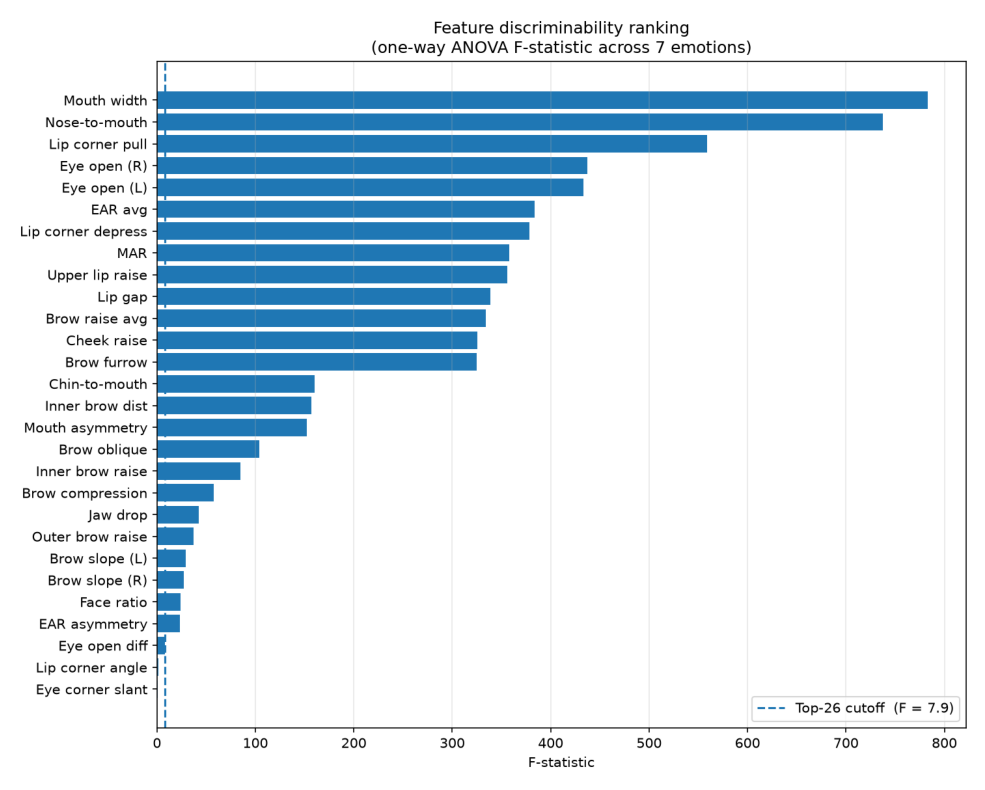

In [2]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'features/figC_feature_ranking.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Median feature values per emotion (heatmap)

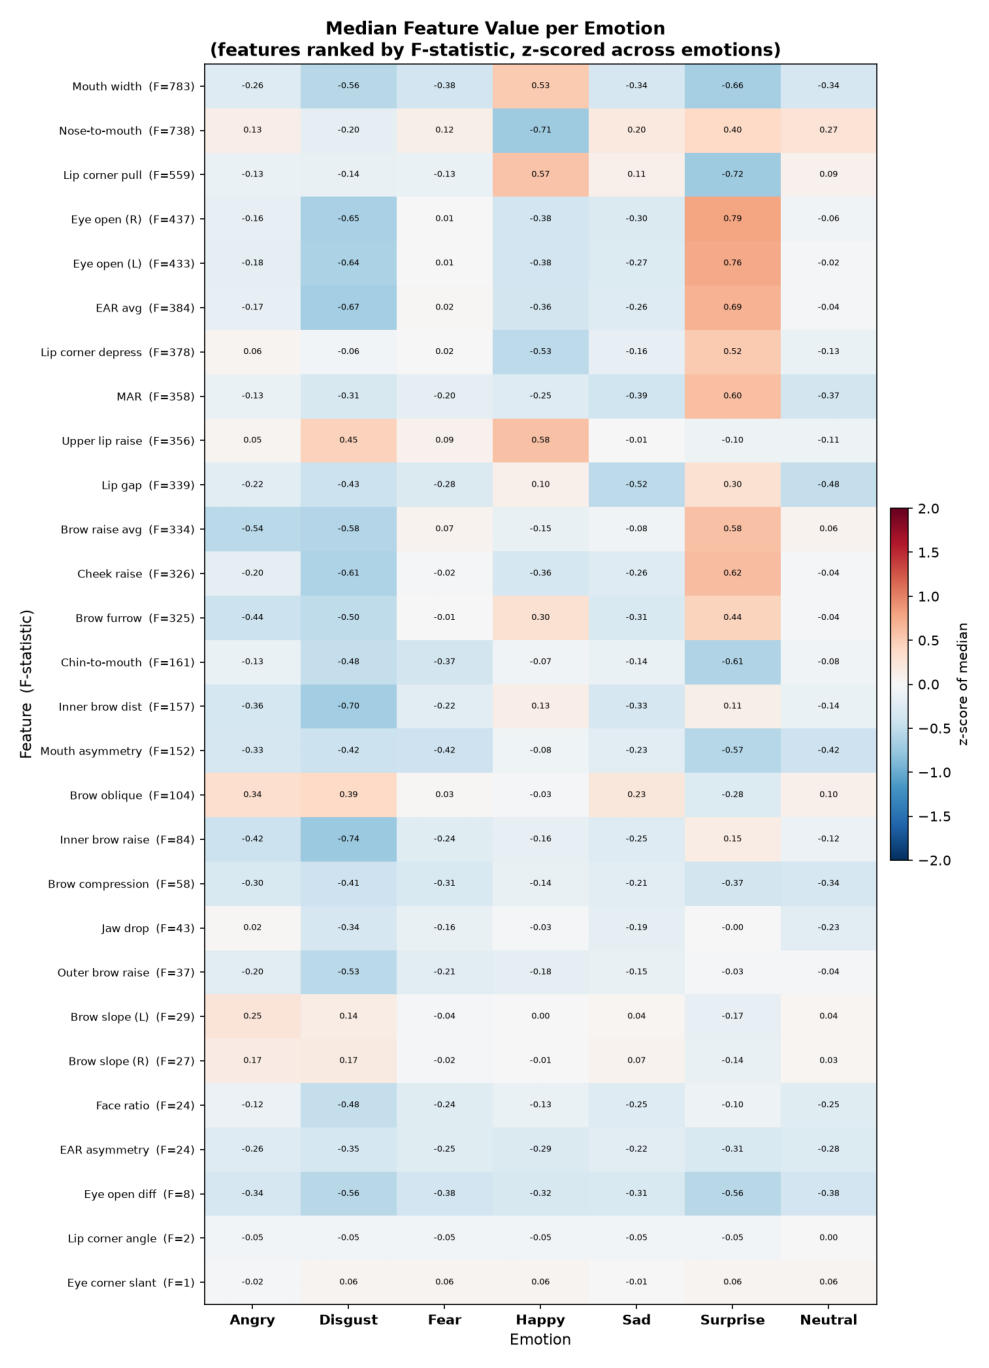

In [3]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'features/figB_feature_heatmap.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(10, 14))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

# Part 2 — SVM Final Models
**⚠️ Requires `appliedml` kernel.**

## Step 9 — RBF kernel SVM grid search

**Script:** `ablation_studies/rbf_parameters.py`  
**Output:** `ablation_results/rbf_grid_search/`  
**Expected runtime: ~40 mins**, if the 'grid_search_results.npy' file is present in ablation_results it will skip the ablation part and run the sample size sweep only

Hyperparameter search for the RBF kernel SVM using courselib's `BinaryKernelSVM`,
which wraps `cvxopt.solvers.qp`
Since cvxopt requires the full N×N kernel matrix in memory (O(N²) ≈ 4GB at
N=22,578), training on the full dataset is infeasible. The grid search uses a
stratified subsample of 6,000 samples.

The grid searches:
- **C ∈ {0.1, 1, 10, 100}**
- **σ ∈ {0.5×, 1×, 2×} × median heuristic** — the median heuristic ($\sigma = \text{median}(\|x_i - x_j\|)$) provides a data-driven baseline; the grid explores symmetrically around it

The script also runs a **sample size sweep** (1k → 6k) to verify performance
continues to improve with more data, motivating the use of a larger subsample
in the final model.

In [2]:
import subprocess, sys
result = subprocess.run([sys.executable, 'ablation_studies/rbf_parameters.py'], capture_output=False)
print("Return code:", result.returncode)

Optimal feature count from C ablation: 26
Best condition from sweep: up_no_cl
Best scaling from sweep:   clip2 (clip=2.0)
Best C from sweep:         SVM (C=1000)

Loading up_no_cl features...
Full dataset:  Train=(22578, 28)  Test=(5652, 28)
Subsample:     (5996, 26)  (stratified from 6000 target)
Class counts:  [ 835  100  777 1649  849  693 1093]

Computing median heuristic sigma...
Median heuristic sigma: 5.7916
Equivalent sklearn gamma: 0.014906
Sigma grid: [2.8958, 5.7916, 11.5832]

Loading existing grid search results...
  C grid: [0.1, 1.0, 10.0, 100.0]
  Sigma grid: [2.8958, 5.7916, 11.5832]
  Skipping grid search — delete grid_search_results.npy to rerun.
Saved fig_rbf_grid.png → /Users/dogadevrimcelik/Desktop/trial_folder/emotion-recognition-test/ablation_results/rbf_grid_search/
Saved fig_rbf_best_cm.png → /Users/dogadevrimcelik/Desktop/trial_folder/emotion-recognition-test/ablation_results/rbf_grid_search/

Running performance vs sample size sweep...
  n=1000...
    class 0

### Grid search heatmap
Macro F1 across the C × σ grid. Smaller σ (tighter kernel, more local boundary) consistently outperforms larger σ at moderate C, suggesting the RBF benefits from capturing local structure in the 26-dimensional feature space. C=100 is an exception where σ=5.94 outperforms σ=2.90.

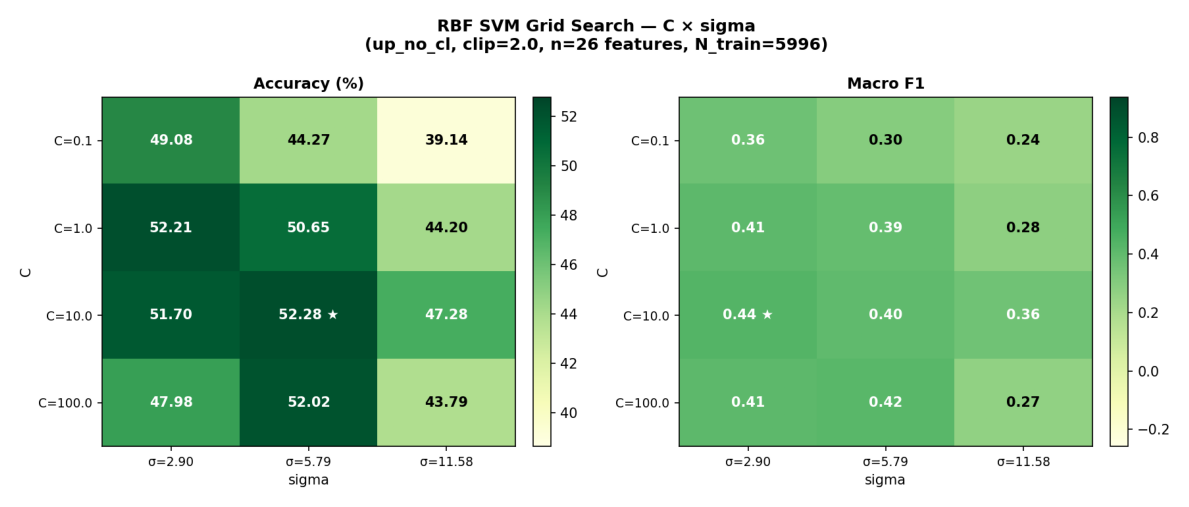

In [3]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'ablation_results/rbf_grid_search/fig_rbf_grid.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Sample size sweep
Performance continues to improve up to 6,000 samples with no plateau, motivating the use of a larger subsample (10,000 samples in final_models.py, full dataset in final_models_v2.py via SMO).

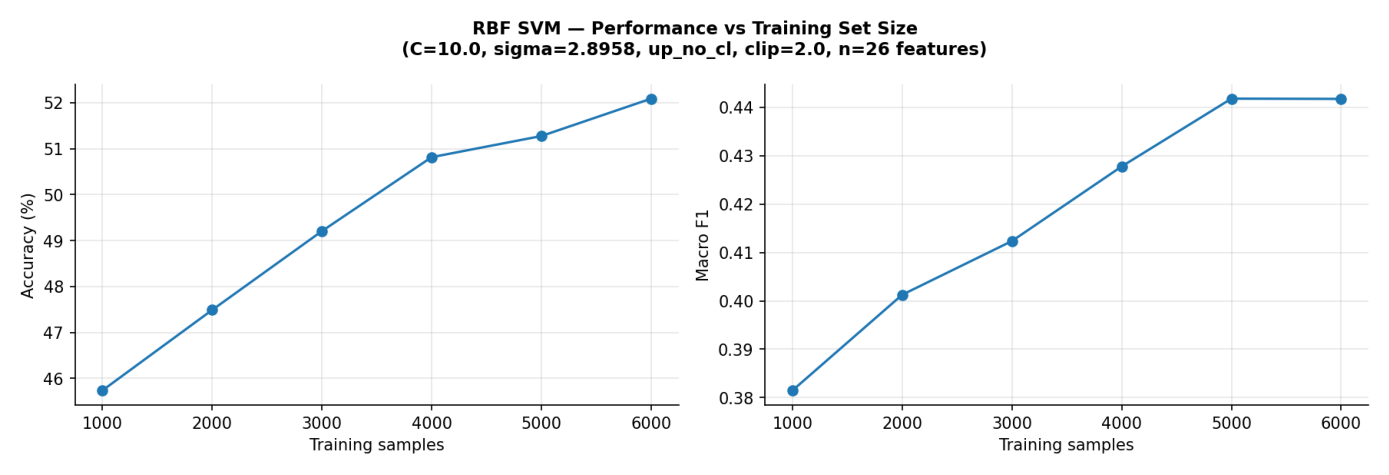

In [4]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'ablation_results/rbf_grid_search/fig_rbf_sample_size.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Best RBF configuration with 6000 samples (grid search subsample)

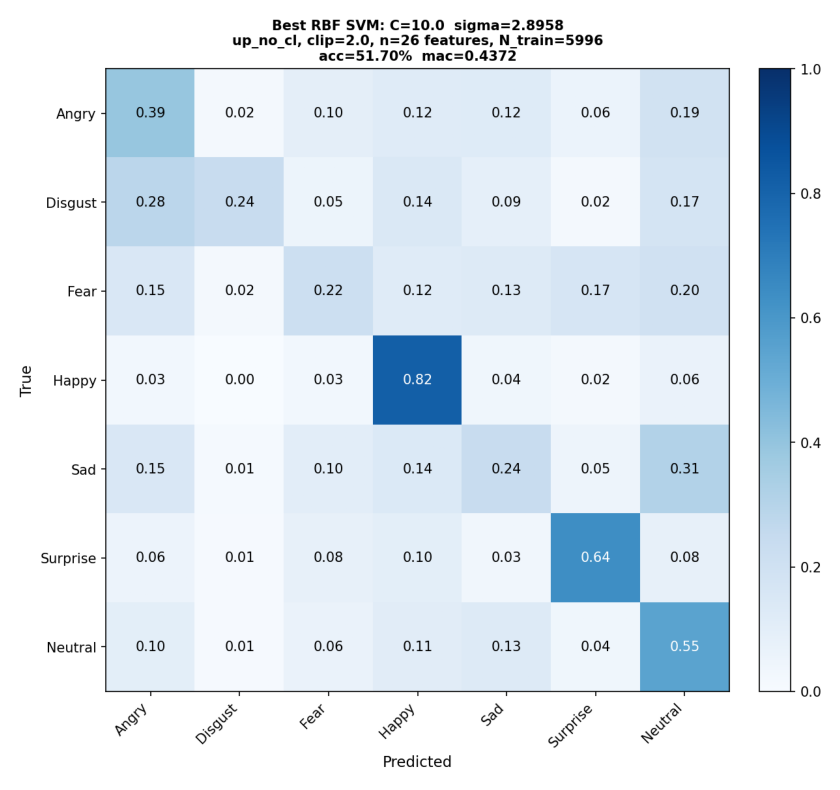

In [6]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'ablation_results/rbf_grid_search/fig_rbf_best_cm.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Grid search results

In [7]:
import numpy as np, os
grid = np.load(os.path.join("ablation_results", "rbf_grid_search",
                             "grid_search_results.npy"), allow_pickle=True).item()
C_grid, sigma_grid, mac_grid = grid["C"], grid["sigma"], grid["mac"]
print("Macro F1 grid:")
print("          " + "  ".join(f"sigma={s:.2f}" for s in sigma_grid))
for ci, C in enumerate(C_grid):
    row = "  ".join(f"{mac_grid[ci, si]:.4f}" for si in range(len(sigma_grid)))
    print(f"C={C:<7} {row}")
best_ci, best_si = map(int, np.unravel_index(np.argmax(mac_grid), mac_grid.shape))
print(f"\nBest: C={C_grid[best_ci]}, sigma={sigma_grid[best_si]:.4f}, "
      f"mac={mac_grid[best_ci, best_si]:.4f}")

Macro F1 grid:
          sigma=2.90  sigma=5.79  sigma=11.58
C=0.1     0.3631  0.2976  0.2418
C=1.0     0.4135  0.3864  0.2774
C=10.0    0.4372  0.4042  0.3618
C=100.0   0.4120  0.4218  0.2666

Best: C=10.0, sigma=2.8958, mac=0.4372


## Step 10 — Final models (cvxopt, 10k subsample)

**Script:** `models/svm/final_models.py`  
**Output:** `model_results/svm/final_models/`  
**Expected runtime: 25 minutes**

Trains and evaluates the two best models using the hyperparameters found in
Steps 8–9:

**Linear SVM** — C=1000, `up_no_cl`, clip2, balanced class weighting, 100 epochs,
inverse-decay LR schedule. The RNG state is reproduced exactly by replaying
150,300 prior `np.random.permutation` calls (the exact number consumed by the
ablation script before reaching the winning configuration), ensuring this run
produces identical results to the ablation.

**RBF SVM** — C=10, σ=2.8958, trained on a stratified subsample of 10,000 samples
using courselib's cvxopt QP solver (the largest subsample that fits in memory
on consumer hardware with 16GB RAM).

In [9]:
import subprocess, sys
result = subprocess.run([sys.executable, 'models/svm/final_models.py'], capture_output=False)
print("Return code:", result.returncode)

Loading features from /Users/dogadevrimcelik/Desktop/trial_folder/emotion-recognition-test/features/ (condition: up_no_cl)...
Full dataset:  Train=(22578, 26)  Test=(5652, 26)

  LINEAR SVM — best macro F1 config
C=1000.0  class_weight=balanced  lr=0.01  decay=0.1
  Replaying prior RNG draws to reproduce ablation RNG state...
  RNG state reproduced.
  Epoch  20  acc=46.51%  mac=0.3901
  Epoch  40  acc=46.62%  mac=0.3913
  Epoch  60  acc=46.28%  mac=0.3882
  Epoch  80  acc=46.30%  mac=0.3880
  Epoch 100  acc=46.74%  mac=0.3917

Linear SVM final:  acc=0.4674  mac=0.3917
Saved → /Users/dogadevrimcelik/Desktop/trial_folder/emotion-recognition-test/model_results/svm/final_models/fig_linear_learning_curve.png
Saved → /Users/dogadevrimcelik/Desktop/trial_folder/emotion-recognition-test/model_results/svm/final_models/fig_linear_cm.png
Saved → /Users/dogadevrimcelik/Desktop/trial_folder/emotion-recognition-test/model_results/svm/final_models/fig_linear_misclassifications.png

  RBF SVM — best g

### Learning curves

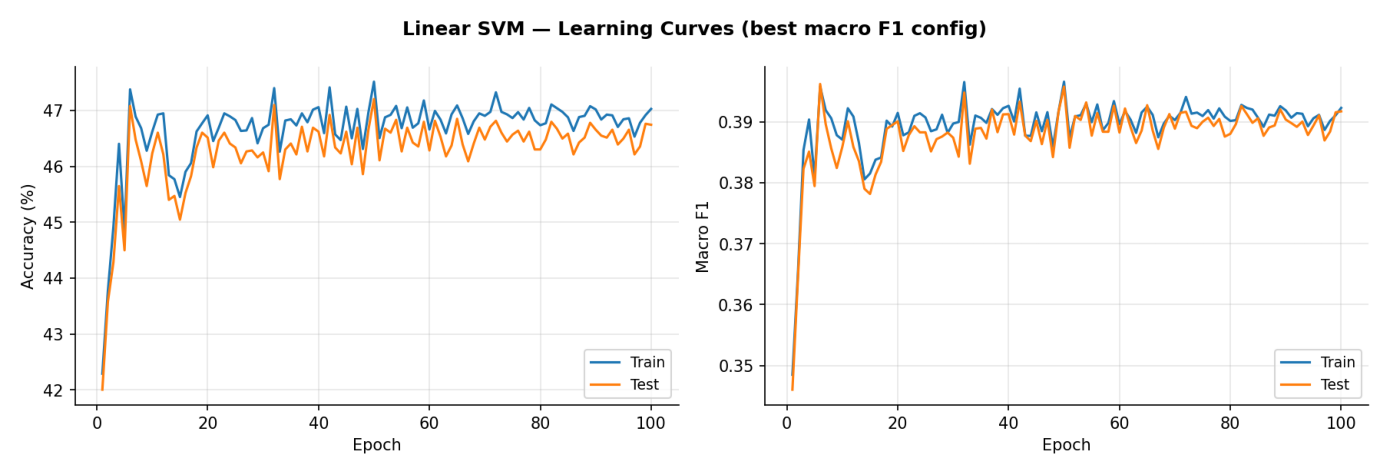

In [10]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'model_results/svm/final_models/fig_linear_learning_curve.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Linear SVM confusion matrix

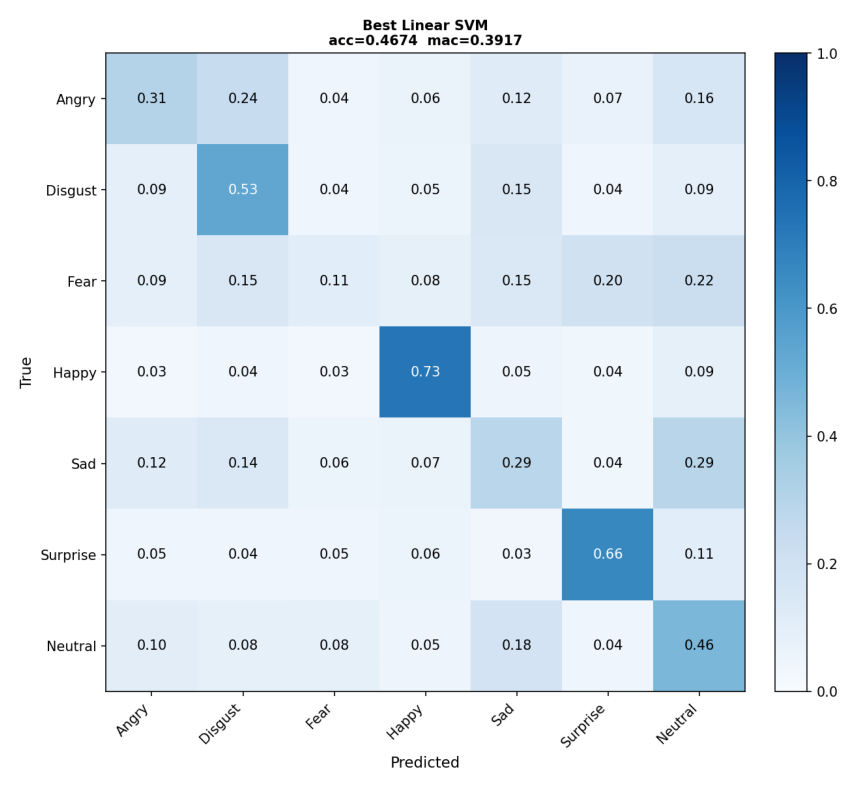

In [11]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'model_results/svm/final_models/fig_linear_cm.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### RBF SVM confusion matrix (10,000 samples, cvxopt)

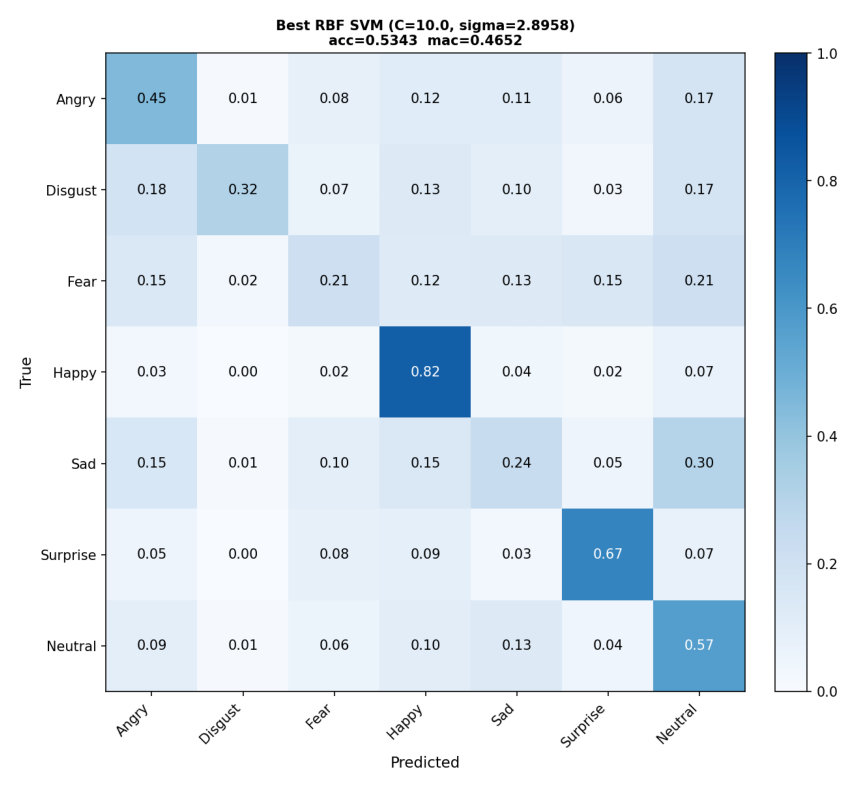

In [12]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'model_results/svm/final_models/fig_rbf_cm.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Linear vs RBF comparison

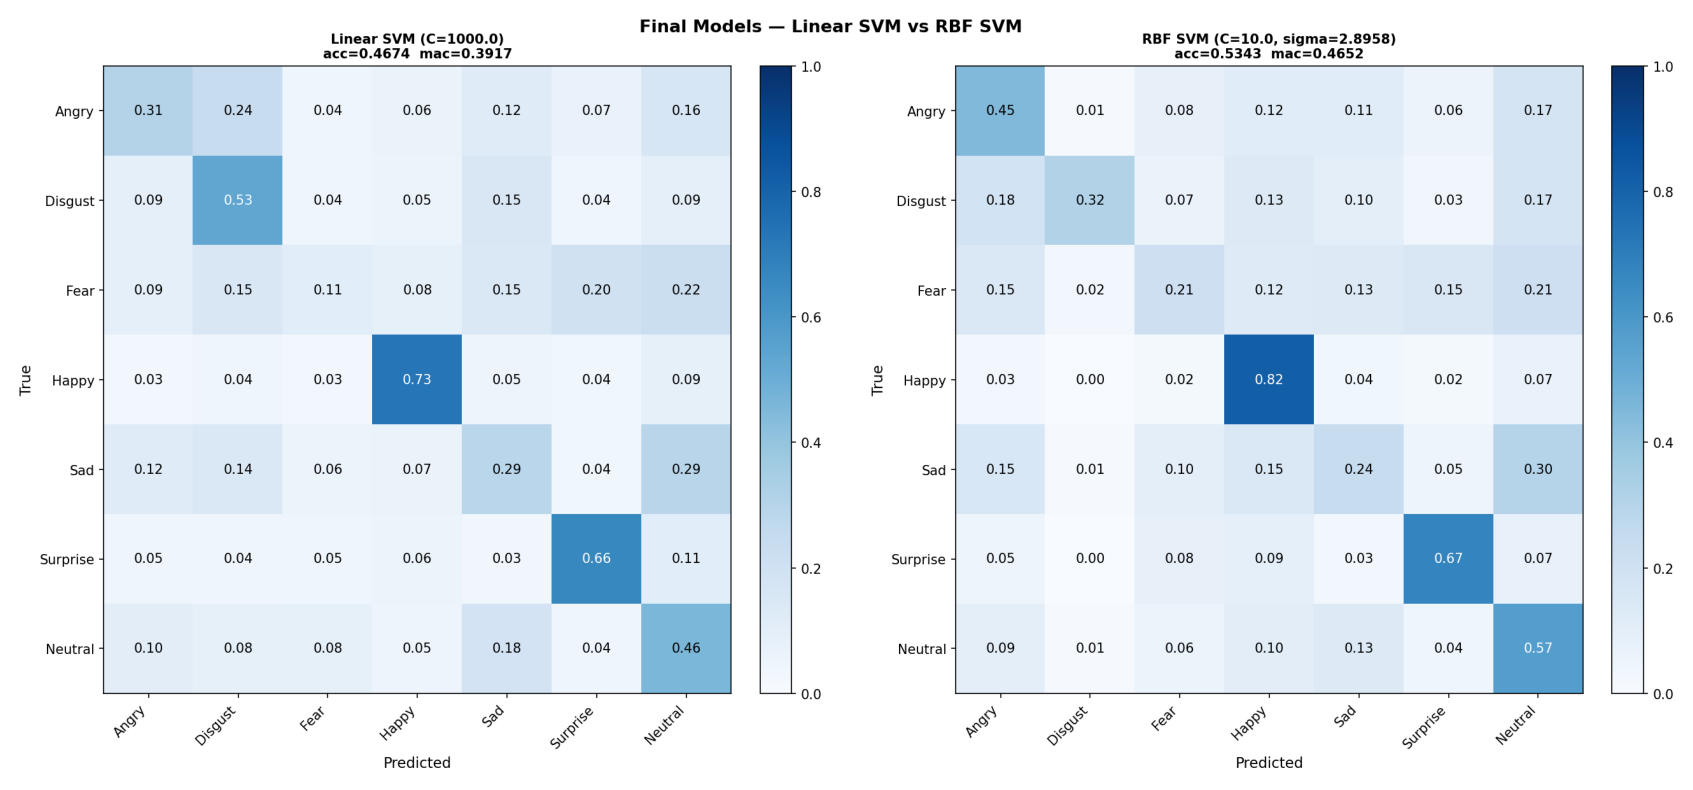

In [13]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'model_results/svm/final_models/fig_linear_vs_rbf_cm.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(18, 8))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Linear SVM misclassifications

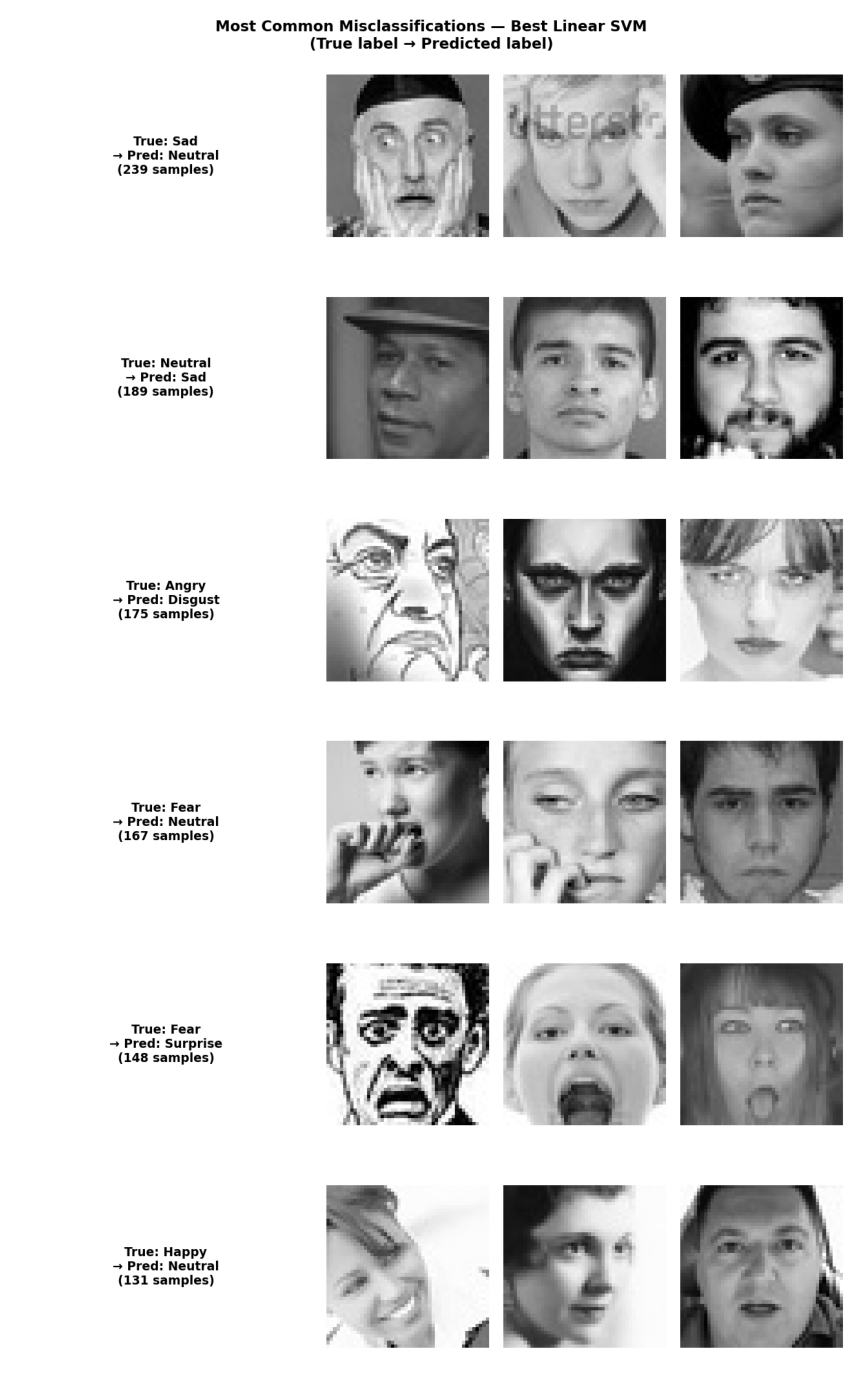

In [14]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'model_results/svm/final_models/fig_linear_misclassifications.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(12, 14))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### RBF SVM misclassifications

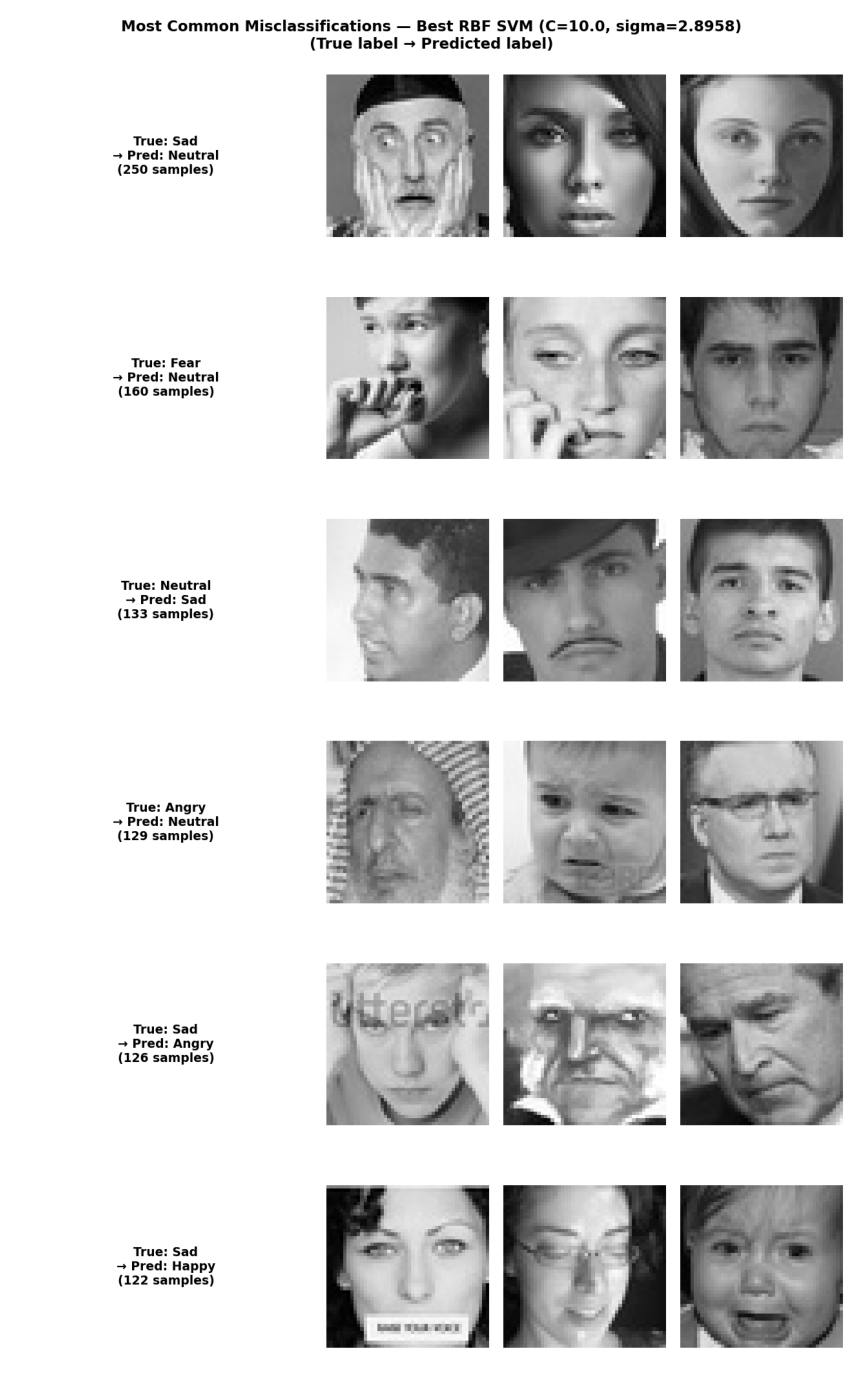

In [15]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'model_results/svm/final_models/fig_rbf_misclassifications.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(12, 14))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Results summary

In [16]:
with open("model_results/svm/final_models/final_results_summary.txt") as f:
    print(f.read())

FINAL MODEL RESULTS SUMMARY
Condition: up_no_cl  |  Scale: clip2.0  |  n_features: 26

LINEAR SVM
  config: C=1000.0, class_weight=balanced, lr=0.01, decay=0.1
  acc=0.4674  mac=0.3917
    Angry      recall=0.308
    Disgust    recall=0.533
    Fear       recall=0.105
    Happy      recall=0.734
    Sad        recall=0.286
    Surprise   recall=0.664
    Neutral    recall=0.460

RBF SVM (courselib cvxopt)
  config: C=10.0, sigma=2.8958, N_train=9996
  acc=0.5343  mac=0.4652
    Angry      recall=0.448
    Disgust    recall=0.315
    Fear       recall=0.214
    Happy      recall=0.820
    Sad        recall=0.241
    Surprise   recall=0.674
    Neutral    recall=0.567



## Step 11 — RBF SVM reference result (sklearn SVC, full dataset)

**Script:** `models/svm/final_models_sklearn.py`  
**Output:** `model_results/svm/final_models_sklearn/`  
**Runtime: 15 seconds**

Trains the same best RBF configuration (C=10, σ=2.8958) on the full 22,578-sample
training set using sklearn's `SVC`, which uses libsvm's SMO solver internally.
Unlike courselib's `BinaryKernelSVM` (cvxopt), sklearn's SVC never constructs
the full N×N kernel matrix. Kernel values are computed on demand, reducing
memory usage from O(N²) to O(N) and making full-dataset training feasible.

This result is reported as a reference/upper bound alongside the courselib
result (Step 10, 10,000 samples), demonstrating what the same hyperparameters
achieve when the solver bottleneck is removed.

The sigma → gamma conversion follows sklearn's convention:
$$\gamma = \frac{1}{2\sigma^2} = \frac{1}{2 \times 2.8958^2} \approx 0.0596$$

In [17]:
import subprocess, sys
result = subprocess.run([sys.executable, 'models/svm/final_models_sklearn.py'], capture_output=False)
print("Return code:", result.returncode)

Loading features from /Users/dogadevrimcelik/Desktop/trial_folder/emotion-recognition-test/features/...
Full dataset:  Train=(22578, 26)  Test=(5652, 26)

Class counts (train): [3144  378 2927 6208 3196 2610 4115]
gamma = 1/(2*sigma^2) = 1/(2*2.8958^2) = 0.059626

  RBF SVM — sklearn SVC (libsvm SMO, full dataset)
C=10.0  sigma=2.8958  gamma=0.059626
N_train=22578 (full dataset)

Note: sklearn SVC uses libsvm's SMO internally — never builds the full
N×N kernel matrix, so full-dataset training is feasible.
[LibSVM]......*...*
optimization finished, #iter = 9469
obj = -4713.240692, rho = -1.213820
nSV = 1079, nBSV = 387
....................*..........*
optimization finished, #iter = 30999
obj = -24960.040641, rho = -0.220898
nSV = 4165, nBSV = 2304
...............*........*
optimization finished, #iter = 23653
obj = -13252.731988, rho = -0.292828
nSV = 2788, nBSV = 1096
......................*..........*
optimization finished, #iter = 32443
obj = -25932.355367, rho = -0.152205
nSV = 4307

### RBF SVM confusion matrix (sklearn SVC, full dataset)

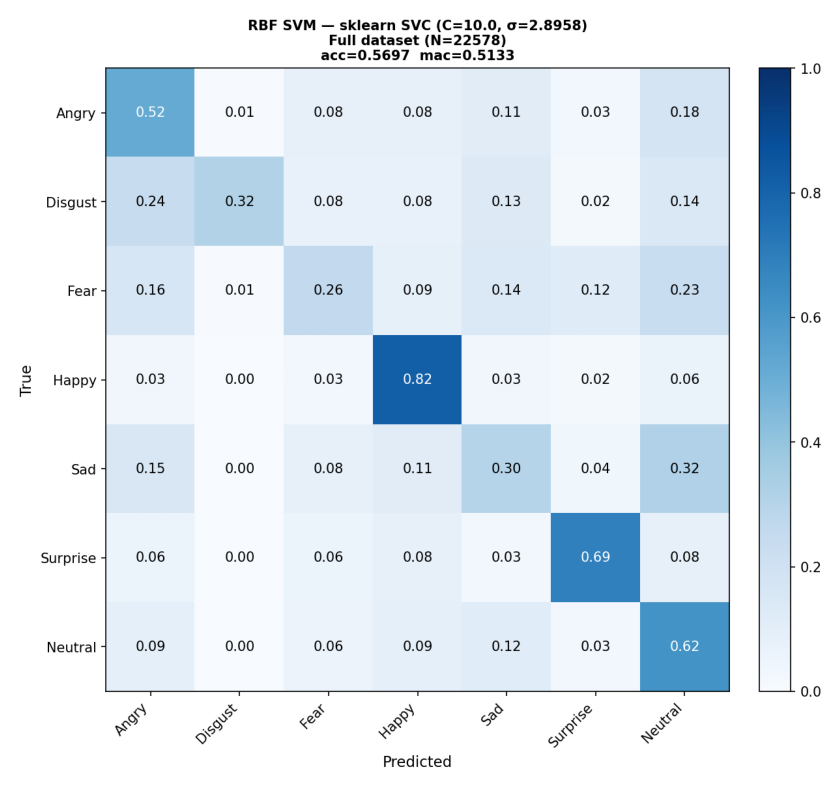

In [18]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'model_results/svm/final_models_sklearn/fig_rbf_sklearn_cm.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Misclassifications — RBF SVM (sklearn, full dataset)

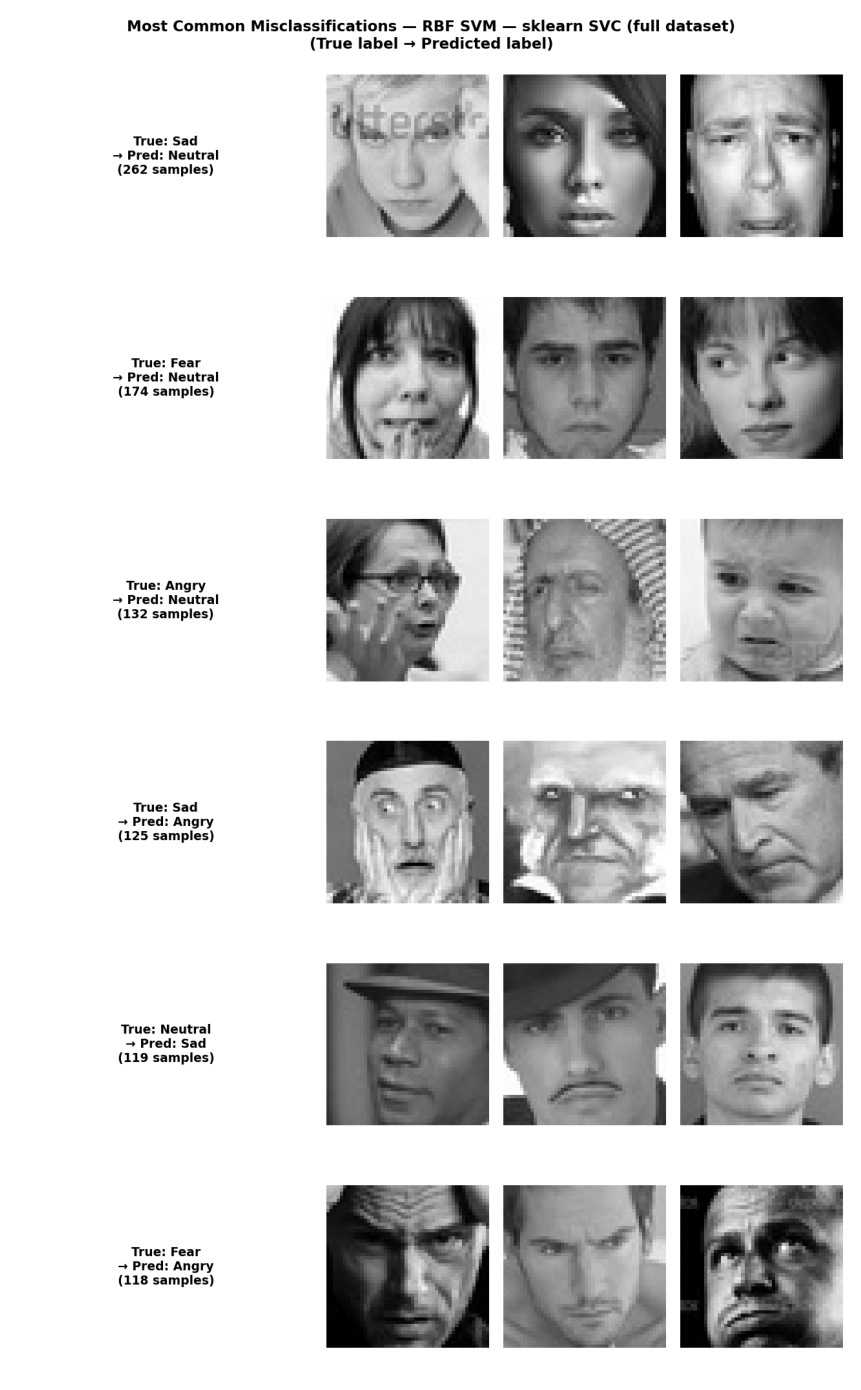

In [19]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os
fname = 'model_results/svm/final_models_sklearn/fig_rbf_sklearn_misclassifications.png'
if os.path.exists(fname):
    img = mpimg.imread(fname)
    fig, ax = plt.subplots(figsize=(12, 14))
    ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print(f"Not found: {fname} — run the script cell above first.")

### Results summary

In [20]:
with open("model_results/svm/final_models_sklearn/final_results_summary.txt") as f:
    print(f.read())

RBF SVM — sklearn SVC (libsvm SMO, full dataset)
C=10.0  sigma=2.8958  gamma=0.059626
N_train=22578 (full FER-2013 training set)
Solver: sklearn SVC (libsvm SMO — no full kernel matrix)
Training time: 7.1s
Total support vectors: 17375

acc=0.5697  mac=0.5133

  Angry      recall=0.517
  Disgust    recall=0.315
  Fear       recall=0.262
  Happy      recall=0.819
  Sad        recall=0.300
  Surprise   recall=0.690
  Neutral    recall=0.620


---
# Results Summary

| Model | Solver | Training samples | Accuracy | Macro F1 |
|-------|--------|-----------------|----------|----------|
| Linear SVM (C=1000, clip2, balanced) | SGD + inv. decay | 22,578 (full) | 0.4674 | 0.3917 |
| RBF SVM (C=10, σ=2.90) | courselib cvxopt QP | 10,000 (subsample) | 0.5343 | 0.4652 |
| RBF SVM (C=10, σ=2.90) | sklearn SVC (libsvm SMO) | 22,578 (full) | 0.5697 | 0.5133 |

All figures and saved models are in `model_results/svm/`.

### Key findings
- **Preprocessing**: 144×144 upscaling improves dlib detection by ~9pp; CLAHE degrades landmark quality despite improving visual contrast.
- **Feature selection**: Top-26 of 28 FACS-inspired geometric features (by ANOVA F-statistic); the 2 dropped features have F<3 and no discriminative power.
- **Linear SVM**: C=1000 is best within the grid; class weighting recovers Disgust recall (0%→53%) at ~5pp accuracy cost; FER-2013 is not linearly separable in this 26-dim feature space
- **RBF SVM (courselib)**: Outperforms linear SVM on macro F1; courselib's cvxopt QP solver is memory-limited to ~10k samples due to its O(N²) kernel matrix requirement.
- **RBF SVM (sklearn)**: Same hyperparameters on the full dataset via libsvm's SMO — further improves macro F1, trains in ~11 seconds, confirming the solver was the bottleneck.